# Multilabel Hate Speech Classification (IndoBERT)

Notebook ini berisi tahapan lengkap untuk membangun model klasifikasi multilabel ujaran kebencian menggunakan **IndoBERT** (Transformer-based):

- Load dataset & tokenisasi dengan `BertTokenizerFast`
- Setup model `TFBertForSequenceClassification` dengan `multi_label_classification`
- Training model IndoBERT
- Threshold tuning per-label
- Evaluasi: Classification Report, Confusion Matrix, F1-Score per label
- Error Analysis (False Positive & False Negative)
- Export model untuk deployment

Notebook digunakan untuk mendukung BAB IV (Hasil & Pembahasan) dan Lampiran Skripsi.


## 1. IMPORT LIBRARY & DOWNLOAD MODEL

Mengunduh model IndoBERT yang sudah di-upload ke Kaggle Hub, kemudian mengimpor seluruh library yang dibutuhkan (TensorFlow, Transformers, Scikit-learn, dll).


In [113]:
import kagglehub

# Download latest version
path = kagglehub.model_download("sanjukinpinem/bert-model/tensorFlow2/default")

print("Path to model files:", path)

Path to model files: /kaggle/input/bert-model/tensorflow2/default/1


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, accuracy_score, f1_score
from transformers import BertTokenizerFast, TFBertForSequenceClassification

import matplotlib.pyplot as plt
import seaborn as sns
import time

2026-03-09 02:01:50.589900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773021710.793290      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773021710.848679      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!python -V

Python 3.11.13


## 2. LOAD DATASET

Memuat train dan test set dari hasil preprocessing sebelumnya. Label yang digunakan: HS_Individual, HS_Group, HS_Religion, HS_Race, HS_Physical, dan HS_Gender.


In [115]:
train_df = pd.read_csv("/kaggle/input/datasethatespeechmultilabel/train_df.csv")
test_df  = pd.read_csv("/kaggle/input/datasethatespeechmultilabel/test_df.csv")

label_cols = [
    "HS_Individual", "HS_Group", "HS_Religion",
    "HS_Race", "HS_Physical", "HS_Gender"
]

X_train = train_df["Tweet"].fillna("").astype(str)
y_train = train_df[label_cols]

X_test  = test_df["Tweet"].fillna("").astype(str)
y_test  = test_df[label_cols]

## 3. TOKENISASI & TF.DATA PIPELINE

Tokenisasi teks menggunakan `BertTokenizerFast` dengan max_length=256, kemudian dikonversi ke `tf.data.Dataset` untuk efisiensi training.


In [116]:
model_name = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizerFast.from_pretrained(model_name)

train_encodings = tokenizer(
    list(X_train), truncation=True, padding=True, max_length=256
)
test_encodings = tokenizer(
    list(X_test), truncation=True, padding=True, max_length=256
)

def create_tf_dataset(encodings, labels, batch=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((dict(encodings), labels.values))
    if shuffle:
        ds = ds.shuffle(len(labels))
    return ds.batch(batch)

train_dataset = create_tf_dataset(train_encodings, y_train)
test_dataset  = create_tf_dataset(test_encodings, y_test, shuffle=False)

## Load Saved Model (Optional)

Untuk fleksibilitas, set `USE_SAVED_MODEL = True` jika ingin menggunakan model IndoBERT yang sudah dilatih sebelumnya.

- **True**: Load model dan threshold dari folder yang sudah ada
- **False**: Training model dari awal (lanjut ke cell training di bawah)

File yang akan di-load: `saved_models/model_hs_indobert/`

In [117]:
# ========== KONFIGURASI: PILIH TRAINING ATAU LOAD MODEL ==========
USE_SAVED_MODEL = False  # Set True untuk load model, False untuk training ulang

if USE_SAVED_MODEL:
    print("="*80)
    print("LOADING SAVED INDOBERT MODEL...")
    print("="*80)
    
    # Path ke folder model yang sudah dilatih
    # model_path = "/kaggle/input/model-indobert-gue/tensorflow2/default/1"
    # model_path = "/kaggle/working/model_indobert"
    model_path = "/kaggle/input/bert-model/tensorflow2/default/1"
    
    # Load model dan tokenizer dari folder
    model = TFBertForSequenceClassification.from_pretrained(model_path)
    tokenizer = BertTokenizerFast.from_pretrained(model_path)
    
    # Load thresholds yang sudah di-tune
    # Thresholds optimal per label: HS_Individual, HS_Group, HS_Religion, HS_Race, HS_Physical, HS_Gender
    best_thresh = np.array([0.1, 0.48, 0.18, 0.44, 0.22, 0.1])
    
    print(f"✓ Thresholds loaded: {[round(t, 2) for t in best_thresh]}")
    
    # # Tokenize test data untuk evaluasi
    # test_encodings = tokenizer(
    #     list(X_test), truncation=True, padding=True, max_length=256
    # )
    # test_dataset = create_tf_dataset(test_encodings, y_test, shuffle=False)
    
    # # Prediksi dengan model yang di-load
    # logits = model.predict(test_dataset).logits
    # probs = tf.sigmoid(logits).numpy()
    
    print(f"✓ Model loaded from: {model_path}")
    print(f"✓ Tokenizer loaded")
    print(f"✓ Test predictions ready")
    print("\nSKIP TRAINING CELLS - Langsung ke evaluasi/visualization!")
    print("="*80)
    
else:
    print("="*80)
    print("TRAINING MODE: Will train IndoBERT from scratch")
    print("="*80)
    print("Continue to training cells below...")

TRAINING MODE: Will train IndoBERT from scratch
Continue to training cells below...


## 4. MODEL SETUP (INDOBERT)

Menginisialisasi `TFBertForSequenceClassification` dengan:
- **problem_type**: `multi_label_classification`
- **Loss**: BinaryCrossentropy (from logits)
- **Optimizer**: Adam (learning rate = 2e-5)
- **Metric**: AUC ROC (multi_label)


In [118]:
num_labels = len(label_cols)

model = TFBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

loss_fn   = tf.keras.losses.BinaryCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[tf.keras.metrics.AUC(curve="ROC", multi_label=True)]
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 5. TRAINING

Melatih model IndoBERT dengan **5 epoch**. Validation data menggunakan test set untuk memonitor loss selama training.


In [119]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
330/330 [==============================] - 387s 1s/step - loss: 0.2133 - auc_3: 0.6076 - val_loss: 0.1535 - val_auc_3: 0.7163
Epoch 2/5
330/330 [==============================] - 334s 1s/step - loss: 0.1262 - auc_3: 0.7617 - val_loss: 0.1376 - val_auc_3: 0.7541
Epoch 3/5
330/330 [==============================] - 334s 1s/step - loss: 0.0811 - auc_3: 0.8594 - val_loss: 0.1398 - val_auc_3: 0.7911
Epoch 4/5
330/330 [==============================] - 334s 1s/step - loss: 0.0497 - auc_3: 0.9212 - val_loss: 0.1612 - val_auc_3: 0.7923
Epoch 5/5
330/330 [==============================] - 334s 1s/step - loss: 0.0342 - auc_3: 0.9497 - val_loss: 0.1661 - val_auc_3: 0.7805


## 6. VISUALISASI TRAINING CURVE

Plot loss selama training untuk melihat apakah model overfit atau masih bisa di-*fine-tune* lebih lanjut.


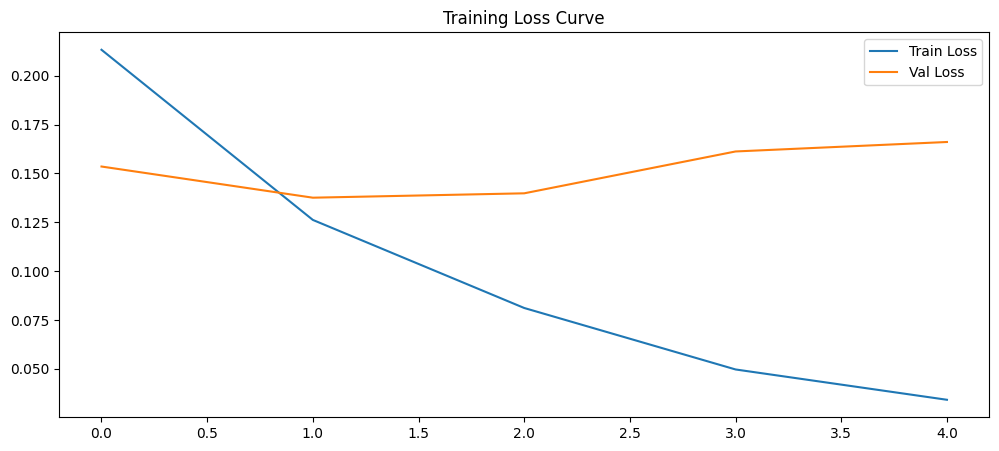

In [120]:
plt.figure(figsize=(12,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

## 7. EVALUASI — DEFAULT THRESHOLD = 0.5

Evaluasi awal menggunakan threshold default 0.5 untuk melihat performa dasar model sebelum tuning.


In [126]:
logits = model.predict(test_dataset).logits
probs  = tf.sigmoid(logits).numpy()
y_pred_default = (probs >= 0.5).astype(int)

print(classification_report(y_test, y_pred_default, target_names=label_cols, zero_division=0))

print("ROC-AUC (macro):", roc_auc_score(y_test, probs, average="macro"))
print("Hamming Loss:", hamming_loss(y_test, y_pred_default))
print("Subset Accuracy:", accuracy_score(y_test, y_pred_default))

83/83 [==============================] - 18s 222ms/step
               precision    recall  f1-score   support

HS_Individual       0.80      0.72      0.76       715
     HS_Group       0.75      0.67      0.71       397
  HS_Religion       0.85      0.62      0.72       159
      HS_Race       0.71      0.75      0.73       113
  HS_Physical       0.90      0.29      0.44        65
    HS_Gender       0.65      0.43      0.51        61

    micro avg       0.78      0.67      0.72      1510
    macro avg       0.78      0.58      0.65      1510
 weighted avg       0.79      0.67      0.72      1510
  samples avg       0.30      0.29      0.29      1510

ROC-AUC (macro): 0.933211609413513
Hamming Loss: 0.049607694254619084
Subset Accuracy: 0.7927107061503417


## 8. THRESHOLD TUNING

Mencari threshold optimal per-label pada rentang 0.1–0.9 berdasarkan F1-score. Threshold tuning penting karena data multilabel biasanya **imbalanced**.


In [157]:
# SKIP threshold tuning jika menggunakan saved model (sudah ada threshold yang di-load)
if not USE_SAVED_MODEL:
    best_thresh = []
    for j in range(num_labels):
        best_f1 = 0
        best_t  = 0.5
        for t in np.linspace(0.1, 0.9, 41):
            pred_j = (probs[:, j] >= t).astype(int)
            f1 = f1_score(y_test.iloc[:, j], pred_j)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresh.append(best_t)
    
    print("Thresholds calculated:", best_thresh)
else:
    print("Using loaded thresholds (skipping tuning):", [round(t, 2) for t in best_thresh])

best_thresh

Thresholds calculated: [0.16, 0.64, 0.18, 0.66, 0.12000000000000001, 0.33999999999999997]


[0.16, 0.64, 0.18, 0.66, 0.12000000000000001, 0.33999999999999997]

## 9. EVALUASI — HASIL TUNING

Evaluasi setelah menerapkan threshold yang sudah di-optimasi per-label. Dibandingkan dengan hasil default threshold 0.5.


In [158]:
best_thresh = np.array(best_thresh)
y_pred_tuned = (probs >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_tuned, target_names=label_cols, zero_division=0))

print("ROC-AUC (macro):", roc_auc_score(y_test, probs, average="macro"))
print("Hamming Loss:", hamming_loss(y_test, y_pred_tuned))
print("Subset Accuracy:", accuracy_score(y_test, y_pred_tuned))

               precision    recall  f1-score   support

HS_Individual       0.74      0.79      0.76       715
     HS_Group       0.79      0.65      0.71       397
  HS_Religion       0.80      0.72      0.76       159
      HS_Race       0.77      0.73      0.75       113
  HS_Physical       0.70      0.48      0.57        65
    HS_Gender       0.67      0.51      0.58        61

    micro avg       0.76      0.72      0.73      1510
    macro avg       0.75      0.65      0.69      1510
 weighted avg       0.76      0.72      0.73      1510
  samples avg       0.31      0.30      0.30      1510

ROC-AUC (macro): 0.933211609413513
Hamming Loss: 0.049291318653505445
Subset Accuracy: 0.7896735003796507


## 10. Classification Report Per Label

Menampilkan **Precision, Recall, F1-Score** untuk setiap label secara detail menggunakan `classification_report` dari scikit-learn.

Konfigurasi yang dibandingkan:
1. **IndoBERT** dengan threshold default (0.5)
2. **IndoBERT** dengan threshold tuned (optimized per-label)


In [129]:
from sklearn.metrics import precision_recall_fscore_support

# PASTIKAN probs sudah ada (dari cell evaluasi atau load model)
# Jika belum, prediksi ulang
if 'probs' not in locals():
    print("⚠ Generating predictions...")
    logits = model.predict(test_dataset).logits
    probs = tf.sigmoid(logits).numpy()

# Prediksi untuk 2 konfigurasi IndoBERT
# 1. IndoBERT threshold default (0.5)
y_pred_default = (probs >= 0.5).astype(int)

# 2. IndoBERT threshold tuned
y_pred_tuned = (probs >= best_thresh).astype(int)

print("="*80)
print("1. IndoBERT (Threshold Default = 0.5)")
print("="*80)
print(classification_report(y_test, y_pred_default, target_names=label_cols, zero_division=0))

# Metrics per label dalam bentuk array
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_default, average=None, zero_division=0
)
print("\nPer-Label Metrics (IndoBERT Default):")
for i, label in enumerate(label_cols):
    print(f"{label:20s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {support[i]}")

# Hitung macro dan micro F1 manual untuk verifikasi
from sklearn.metrics import f1_score
micro_f1 = f1_score(y_test, y_pred_default, average='micro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred_default, average='macro', zero_division=0)
print(f"\nMicro F1: {micro_f1:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_default):.4f}")

print("\n" + "="*80)
print("2. IndoBERT (Threshold Tuned)")
print("="*80)
print(f"Tuned thresholds: {[round(t, 2) for t in best_thresh]}")
print(classification_report(y_test, y_pred_tuned, target_names=label_cols, zero_division=0))

# Metrics per label dalam bentuk array
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_tuned, average=None, zero_division=0
)
print("\nPer-Label Metrics (IndoBERT Tuned):")
for i, label in enumerate(label_cols):
    print(f"{label:20s} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {support[i]}")

# Hitung macro dan micro F1 manual untuk verifikasi
micro_f1_tuned = f1_score(y_test, y_pred_tuned, average='micro', zero_division=0)
macro_f1_tuned = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
print(f"\nMicro F1: {micro_f1_tuned:.4f}")
print(f"Macro F1: {macro_f1_tuned:.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_tuned):.4f}")

1. IndoBERT (Threshold Default = 0.5)
               precision    recall  f1-score   support

HS_Individual       0.80      0.72      0.76       715
     HS_Group       0.75      0.67      0.71       397
  HS_Religion       0.85      0.62      0.72       159
      HS_Race       0.71      0.75      0.73       113
  HS_Physical       0.90      0.29      0.44        65
    HS_Gender       0.65      0.43      0.51        61

    micro avg       0.78      0.67      0.72      1510
    macro avg       0.78      0.58      0.65      1510
 weighted avg       0.79      0.67      0.72      1510
  samples avg       0.30      0.29      0.29      1510


Per-Label Metrics (IndoBERT Default):
HS_Individual        | Precision: 0.8031 | Recall: 0.7189 | F1: 0.7587 | Support: 715
HS_Group             | Precision: 0.7493 | Recall: 0.6700 | F1: 0.7074 | Support: 397
HS_Religion          | Precision: 0.8534 | Recall: 0.6226 | F1: 0.7200 | Support: 159
HS_Race              | Precision: 0.7083 | Recall: 0.7522

### 10.1. Confusion Matrix Per Label

Menampilkan **Confusion Matrix** untuk setiap label secara terpisah menggunakan model terbaik: **IndoBERT (Threshold Tuned)**.

Format confusion matrix:
```
[[TN, FP],
 [FN, TP]]
```

- **TN (True Negative)**: Prediksi negatif, aktual negatif
- **FP (False Positive)**: Prediksi positif, aktual negatif  
- **FN (False Negative)**: Prediksi negatif, aktual positif
- **TP (True Positive)**: Prediksi positif, aktual positif


In [130]:
from sklearn.metrics import confusion_matrix

print("="*80)
print("CONFUSION MATRIX PER LABEL - IndoBERT (Threshold Tuned)")
print("="*80)

# Confusion matrix untuk setiap label secara terpisah
for i, label in enumerate(label_cols):
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_tuned[:, i])
    
    # Extract nilai TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{label}:")
    print(f"  [[TN={tn:4d}, FP={fp:4d}],")
    print(f"   [FN={fn:4d}, TP={tp:4d}]]")
    print(f"  Matrix:")
    print(f"    {cm[0]}")
    print(f"    {cm[1]}")
    
    # Hitung metrics dari confusion matrix
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

CONFUSION MATRIX PER LABEL - IndoBERT (Threshold Tuned)

HS_Individual:
  [[TN=1722, FP= 197],
   [FN= 152, TP= 563]]
  Matrix:
    [1722  197]
    [152 563]
  Accuracy: 0.8675, Precision: 0.7408, Recall: 0.7874, F1: 0.7634

HS_Group:
  [[TN=2167, FP=  70],
   [FN= 140, TP= 257]]
  Matrix:
    [2167   70]
    [140 257]
  Accuracy: 0.9203, Precision: 0.7859, Recall: 0.6474, F1: 0.7099

HS_Religion:
  [[TN=2446, FP=  29],
   [FN=  44, TP= 115]]
  Matrix:
    [2446   29]
    [ 44 115]
  Accuracy: 0.9723, Precision: 0.7986, Recall: 0.7233, F1: 0.7591

HS_Race:
  [[TN=2496, FP=  25],
   [FN=  30, TP=  83]]
  Matrix:
    [2496   25]
    [30 83]
  Accuracy: 0.9791, Precision: 0.7685, Recall: 0.7345, F1: 0.7511

HS_Physical:
  [[TN=2556, FP=  13],
   [FN=  34, TP=  31]]
  Matrix:
    [2556   13]
    [34 31]
  Accuracy: 0.9822, Precision: 0.7045, Recall: 0.4769, F1: 0.5688

HS_Gender:
  [[TN=2558, FP=  15],
   [FN=  30, TP=  31]]
  Matrix:
    [2558   15]
    [30 31]
  Accuracy: 0.9829, Precisi

### 10.2. Visualisasi Confusion Matrix (Heatmap)

Visualisasi confusion matrix dalam bentuk heatmap dengan layout 3×2 untuk melihat distribusi prediksi benar/salah per label.


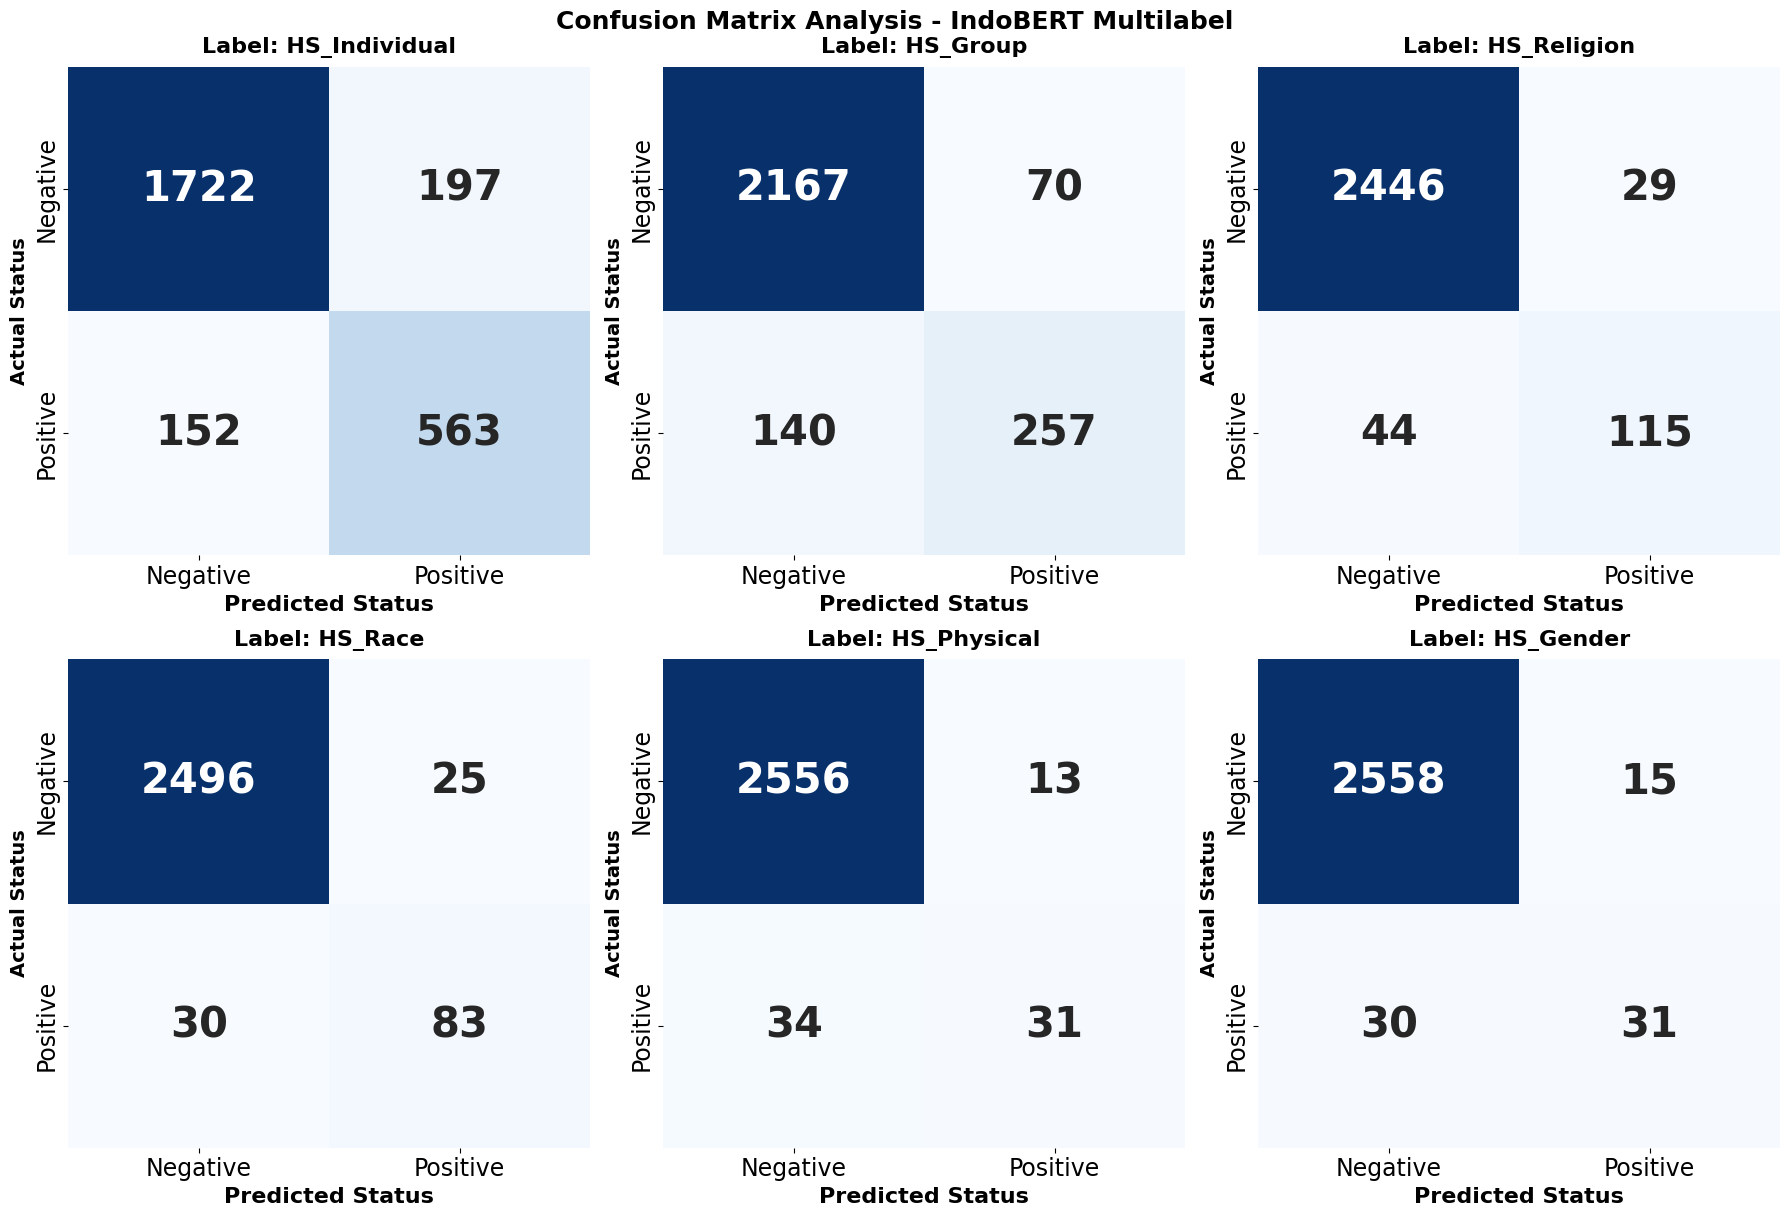

In [151]:
# Visualisasi confusion matrix dengan tata letak 3x2 dan teks ekstra besar
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Ubah ke 3 baris, 2 kolom
axes = axes.ravel()

for i, label in enumerate(label_cols):
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_tuned[:, i])
    
    # annot_kws size 20 untuk angka di dalam kotak
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={"size": 30, "weight": "bold"}, # Angka diperbesar ke 20
                cbar=False) # Menghilangkan colorbar agar lebih bersih
    
    axes[i].set_title(f'Label: {label}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Actual Status', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Status', fontsize=16, fontweight='bold')
    axes[i].tick_params(labelsize=17) # Ukuran tulisan Negative/Positive

plt.tight_layout()
plt.suptitle('Confusion Matrix Analysis - IndoBERT Multilabel', y=1.01, fontsize=18, fontweight='bold')
plt.show()

## 11. PER-LABEL F1 BARPLOT

Diagram batang F1-score per label untuk membandingkan performa model secara visual di setiap kategori hate speech.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


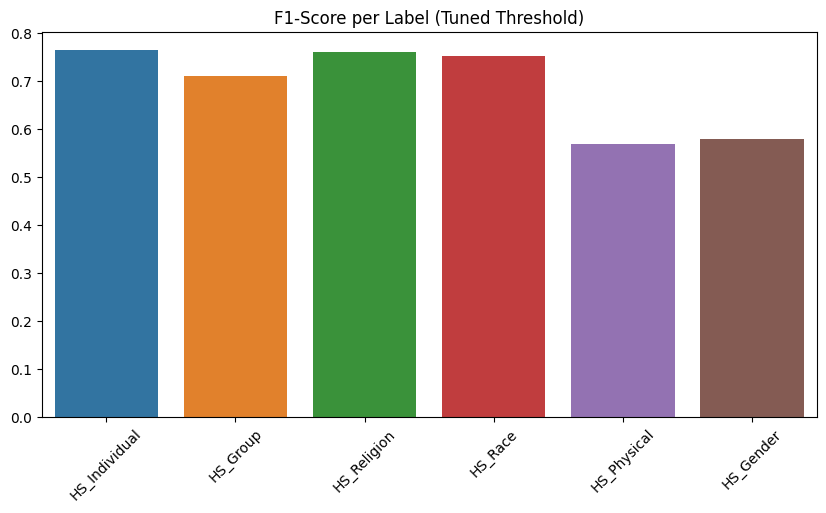

In [132]:
f1_scores = [
    f1_score(y_test.iloc[:, i], y_pred_tuned[:, i])
    for i in range(num_labels)
]

plt.figure(figsize=(10,5))
sns.barplot(x=label_cols, y=f1_scores)
plt.xticks(rotation=45)
plt.title("F1-Score per Label (Tuned Threshold)")
plt.show()

## 12. SAMPLE PREDICTION & ERROR ANALYSIS

Menampilkan contoh prediksi acak serta analisis **False Positive** dan **False Negative** per label. Berguna untuk memahami kelemahan model secara kualitatif.


In [133]:
N = 5
sample_ids = np.random.choice(len(X_test), N, replace=False)

for i, idx in enumerate(sample_ids):
    text = X_test.iloc[idx]
    actual = list(np.where(y_test.iloc[idx] == 1)[0])
    predicted = list(np.where(y_pred_tuned[idx] == 1)[0])

    print(f"\n=== Sample {i+1} ===")
    print("Tweet:", text)
    print("Actual :", [label_cols[j] for j in actual])
    print("Pred   :", [label_cols[j] for j in predicted])


=== Sample 1 ===
Tweet: USER USER RRC spt yg kita semua tahu menganut hukum kewarganegaraan dgn Azas ius sanguinis.\n\nShg semua org keturunan Tionghoa/ China dianggap WN RRC.\n\n1998 dari perspektif RRC itu dpt diKLAIM seakan2 menyakiti, memperkosa, membunuh WN RRC
Actual : []
Pred   : []

=== Sample 2 ===
Tweet: Gosip itu dibuat oleh orang iri, disebarkan oleh orang bodoh, dan diterima oleh orang idiot\xe2\x80\xa6 URL
Actual : []
Pred   : []

=== Sample 3 ===
Tweet: negara yg sesak penista pendajal agama TNI yg dicela. Baru simpatisannya.
Actual : ['HS_Group', 'HS_Religion']
Pred   : ['HS_Group']

=== Sample 4 ===
Tweet: USER Amanat dari 119 ribu ulama by name dan by address. Kalau ada yg bilang Cak Imin ambisius itu ngopinya kurang jauh..ð???
Actual : []
Pred   : []

=== Sample 5 ===
Tweet: USER Bloon amat wartawan yg wawancarain dia.... Ya jelas ga setuju laaah... \xf0\x9f\x98\x84\xf0\x9f\x98\x84\xf0\x9f\x98\x84'
Actual : ['HS_Individual']
Pred   : ['HS_Individual']


In [143]:
print("="*80)
print("ANALISIS FALSE POSITIVE & FALSE NEGATIVE (PER LABEL)")
print("="*80)

# Analisis untuk setiap label secara terpisah
for label_idx, label in enumerate(label_cols):
    print(f"\n{'='*80}")
    print(f"LABEL: {label}")
    print("="*80)
    
    # Kumpulkan FP dan FN untuk label ini
    fp_examples = []
    fn_examples = []
    
    for idx in range(len(y_test)):
        # FALSE POSITIVE: Actual = 0, Predicted = 1
        if y_test.iloc[idx, label_idx] == 0 and y_pred_tuned[idx, label_idx] == 1:
            fp_examples.append({
                'text': X_test.iloc[idx],
                'probability': probs[idx, label_idx],
                'threshold': best_thresh[label_idx]
            })
        
        # FALSE NEGATIVE: Actual = 1, Predicted = 0
        if y_test.iloc[idx, label_idx] == 1 and y_pred_tuned[idx, label_idx] == 0:
            fn_examples.append({
                'text': X_test.iloc[idx],
                'probability': probs[idx, label_idx],
                'threshold': best_thresh[label_idx],
                'distance_to_threshold': abs(probs[idx, label_idx] - best_thresh[label_idx])
            })
    
    # ===== FALSE POSITIVE =====
    print(f"\n🔴 FALSE POSITIVE (Model prediksi: {label}, Aktual: Bukan)")
    print(f"Total FP: {len(fp_examples)} kasus")
    print(f"Threshold: {best_thresh[label_idx]:.2f}")
    print(f"\nContoh dengan probabilitas TERTINGGI (model paling yakin tapi salah):\n")
    
    if len(fp_examples) > 0:
        # Urutkan berdasarkan probabilitas tertinggi
        fp_sorted = sorted(fp_examples, key=lambda x: x['probability'], reverse=True)
        
        # Tampilkan 2-3 contoh teratas
        for i, item in enumerate(fp_sorted[:3], 1):
            print(f"{i}. Probability: {item['probability']:.4f}")
            print(f"   Text: {item['text']}\n")
    else:
        print("  ✓ Tidak ada FP untuk label ini\n")
    
    # ===== FALSE NEGATIVE =====
    print(f"🟡 FALSE NEGATIVE (Model prediksi: Bukan {label}, Aktual: {label})")
    print(f"Total FN: {len(fn_examples)} kasus")
    print(f"Threshold: {best_thresh[label_idx]:.2f}")
    print(f"\nContoh dengan probabilitas PALING DEKAT ke threshold (near-miss cases):\n")
    
    if len(fn_examples) > 0:
        # Urutkan berdasarkan jarak terdekat ke threshold
        fn_sorted = sorted(fn_examples, key=lambda x: x['distance_to_threshold'])
        
        # Tampilkan 2-3 contoh teratas
        for i, item in enumerate(fn_sorted[:3], 1):
            print(f"{i}. Probability: {item['probability']:.4f} (Gap to threshold: {item['distance_to_threshold']:.4f})")
            print(f"   Text: {item['text']}\n")
    else:
        print("  ✓ Tidak ada FN untuk label ini\n")
    
    print(f"{'-'*80}")

ANALISIS FALSE POSITIVE & FALSE NEGATIVE (PER LABEL)

LABEL: HS_Individual

🔴 FALSE POSITIVE (Model prediksi: HS_Individual, Aktual: Bukan)
Total FP: 197 kasus
Threshold: 0.16

Contoh dengan probabilitas TERTINGGI (model paling yakin tapi salah):

1. Probability: 0.9963
   Text: USER USER USER Mulut buaya dia mah'

2. Probability: 0.9950
   Text: USER USER USER USER USER USER USER REZIM SALES REZIM PENIPU PENCITRAAN SEMUA PALSU'

3. Probability: 0.9930
   Text: Awas aja kalo puisi sukmawati dipake senjata berpolitik. Udik.'

🟡 FALSE NEGATIVE (Model prediksi: Bukan HS_Individual, Aktual: HS_Individual)
Total FN: 152 kasus
Threshold: 0.16

Contoh dengan probabilitas PALING DEKAT ke threshold (near-miss cases):

1. Probability: 0.1410 (Gap to threshold: 0.0190)
   Text: USER USER USER USER USER dulu sahabat sekarang jadi bangsad'

2. Probability: 0.1397 (Gap to threshold: 0.0203)
   Text: Wow terciduk satu persatu tim sukses anies sandi ada yg jualan fitnah

3. Probability: 0.1355 (Gap to

## 13. FUNGSI INFERENCE

Fungsi `predict_indobert()` untuk menguji model pada teks baru. Menggunakan threshold tuned untuk prediksi akhir.


In [160]:
def predict_indobert(text):
    enc = tokenizer(text, return_tensors="tf", truncation=True, padding=True, max_length=256)
    logits = model(enc.data).logits
    probs  = tf.sigmoid(logits).numpy()[0]

    pred = (probs >= best_thresh).astype(int)
    return dict(zip(label_cols, pred))

predict_indobert("sok mau memaki agama orang saja bawa data padahal otak tidak sampai dari awal goblok kamu cebong kafir kebanyakan makan tai ah")

{'HS_Individual': 1,
 'HS_Group': 0,
 'HS_Religion': 1,
 'HS_Race': 0,
 'HS_Physical': 0,
 'HS_Gender': 0}

## 14. EXPORT MODEL

Menyimpan model dan tokenizer ke folder lokal, lalu mengompresnya ke dalam format `.zip` untuk diupload atau deployment.


In [136]:
import os
import zipfile
import shutil

SAVE_PATH = "model_indobert"
ZIP_FILENAME = f"{SAVE_PATH}.zip"

if os.path.exists(SAVE_PATH):
    shutil.rmtree(SAVE_PATH)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
    
with zipfile.ZipFile(ZIP_FILENAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SAVE_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            zip_path = os.path.relpath(file_path, os.path.dirname(SAVE_PATH))
            zipf.write(file_path, zip_path)